## Sklearn Version

In [34]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

import time

In [35]:
X,y = load_diabetes(return_X_y=True)

In [36]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [38]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [40]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

## Mathematical Formulation

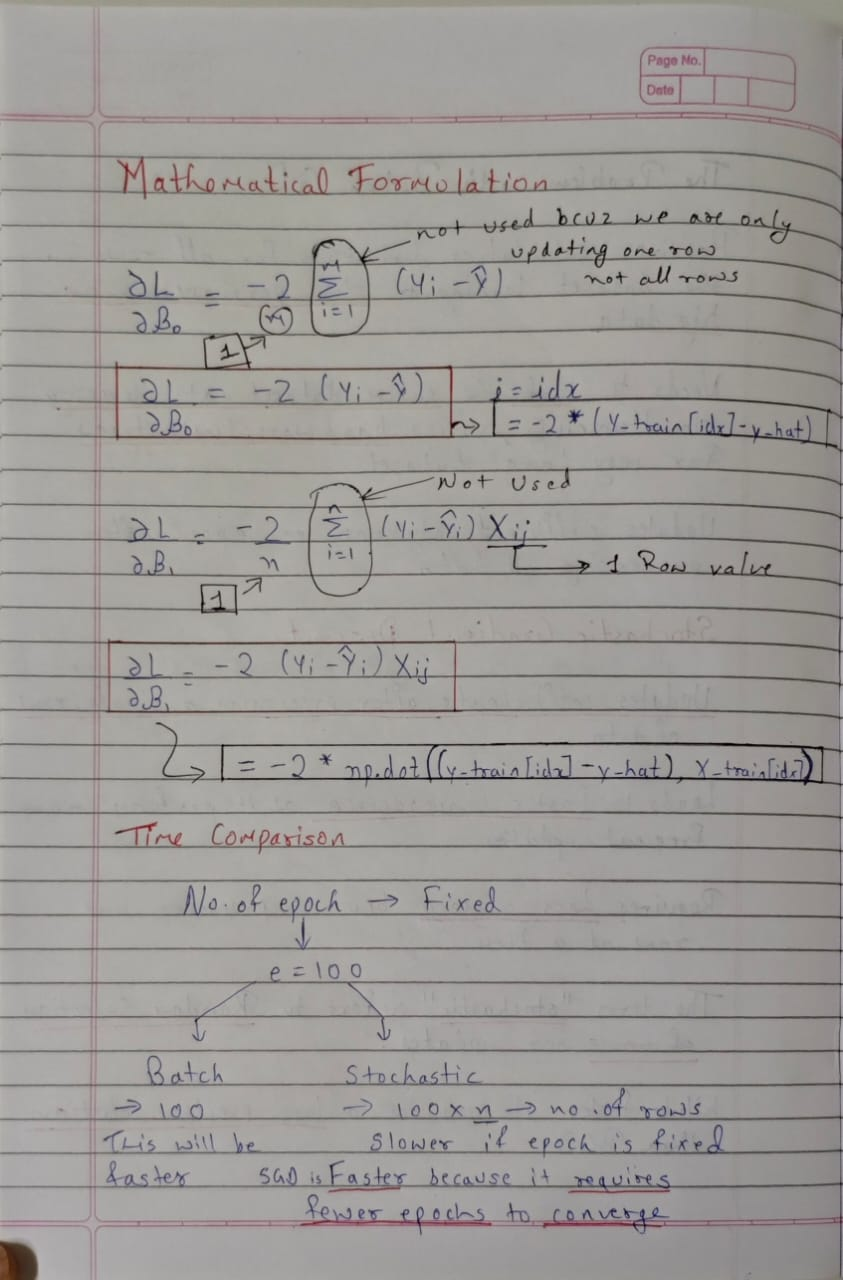

## From Scratch

In [41]:
class SGDRegressor:

    def __init__(self,learning_rate=0.01,epochs=100):

        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):

        # initialize the coefficients and intercept
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])   # creates a 1‑D array filled with 1.0 values of that length

        for i in range(self.epochs):
            for j in range(X_train.shape[0]):
                idx = np.random.randint(0,X_train.shape[0])
                
                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_
    
                intercept_der = -2 * (y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)
    
                coef__der = -2 * np.dot((y_train[idx] - y_hat), X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef__der)

        print(self.intercept_,self.coef_)

    def predict(self,X_test):
         return np.dot(X_test,self.coef_) + self.intercept_

In [42]:
sgd = SGDRegressor(learning_rate=0.01,epochs=40)

In [43]:

start = time.time()
sgd.fit(X_train, y_train)
print("The time taken is",time.time() - start)

148.2438585844881 [  59.03133006  -39.34338922  313.42038967  228.07200374   26.69268795
  -16.5187582  -154.97203986  128.37602033  286.02487851  127.73943774]
The time taken is 0.1206657886505127


In [44]:
y_pred = sgd.predict(X_test)

In [45]:
print("R2:", r2_score(y_test, y_pred))

R2: 0.41610663750687693
